In [30]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from numba import jit, njit
from scipy.stats import  t

In [31]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    # Wiener Process by default
    # use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        xs = x0 + bxt(x0, t0, params) * (t - t0)
        sigma2 = sigmaxt(x0, t0, params)**2 * (t - t0)

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def OzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        K = 1 / (t - t0) * np.log(1 + bxt(x0, t0, params) / (x0 * bxt_x(x0, t0, params)) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1))
        E = x0 + bxt(x0, t0, params) / bxt_x(x0, t0, params) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1)
        V = sigmaxt(x0, t0, params)**2 / (2 * K) * (np.exp(2 * K * (t - t0)) - 1)

        xs = E
        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)

        #safe division
        if L == 0:
            L = L + 0.001

        M = sigmaxt(x0, t0, params)**2 / 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = 1 + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1) + M / (x0 * L**2) * \
            (np.exp(L * (t - t0)) - 1 - L * (t - t0))
        B = sigmaxt(x0, t0, params)**2 * 1/(2 * L) * (np.exp(2 * L * (t - t0)) - 1)

        xs = A * x0
        sigma2 = B

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        E = x0 + bxt(x0, t0, params) * (t - t0) + (bxt(x0, t0, params) * bxt_x(x0, t0, params) + 1/2 * \
            sigmaxt(x0, t0, params)**2 * bxt_xx(x0, t0, params)) * 1/2 * (t - t0)**2
        V = x0**2 + (2 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params)**2 ) * (t - t0)\
            + (2 * bxt(x0, t0, params) * (bxt_x(x0, t0, params) * x0 + bxt(x0, t0, params) + \
                sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params))\
            + sigmaxt(x0, t0, params)**2 * (bxt_xx(x0, t0, params) * x0 + 2 * bxt_x(x0, t0, params) +\
                sigmaxt_x(x0, t0, params)**2 + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params))) * (t - t0)**2 / 2 - E**2

        xs = E

        #safe division
        if V == 0:
            V = V + 0.001

        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit   
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])
        log_data = np.zeros(Nx)
        for k in range(0, Nx):
            m_log_lik = 0
            for j in range(1, Nt):
                m_log_lik += density(x_data[j][k], t_data[j], x_data[j - 1][k], t_data[j - 1], params,
                                     bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t)
            log_data[k] = m_log_lik

        res = -np.mean(log_data)
        return res

    def EulerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.EulerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def OzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.OzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def ShojiOzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.ShojiOzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def KesslerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.KesslerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta, mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

class CKLSprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * x**params[3]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * params[3] * x**(params[3] - 1)

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return params[2] * params[3] * (params[3] - 1) * x**(params[3] - 2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class Task5process(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0] * t

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * x

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class HullWhiteprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * (params[1] * np.sqrt(t) - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * t

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0] * t

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * params[1] * 3/2 * np.sqrt(t)

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

Task 1. Evaluate the conditional density of the Ornstein-Uhlenbeck process
$$dX_t = (3-X_t)dt+2dW_t, \quad X_0=1, \quad %\theta=(1, 3, 2), \quad
N=100000,
\quad \Delta=1$$ and calculate the
maximum likelihood estimation.  

In [32]:
Nx = 100000
Nt = 300

T = 1

params_OU = np.array([3, 1, 2])

x0 = 1
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [33]:
OUp.EulerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.93195316181937
        x: [ 3.002e+00  9.993e-01  2.000e+00]
      nit: 16
      jac: [ 5.087e-04 -2.558e-05  2.157e-03]
     nfev: 72
     njev: 18
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [34]:
OUp.ShojiOzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.93195310706093
        x: [ 3.017e+00  9.993e-01  2.010e+00]
      nit: 15
      jac: [-4.917e-04 -8.384e-04 -2.393e-03]
     nfev: 68
     njev: 17
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [35]:
OUp.KesslerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.9319523226894
        x: [ 3.016e+00  9.996e-01  2.010e+00]
      nit: 15
      jac: [ 1.904e-04  4.263e-04  5.258e-04]
     nfev: 72
     njev: 18
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Find the maximum likelihood estimators  numerically
 for Ornstein-Uhlenbeck process
 $$
 dX_t = -\theta_2X_tdt + \theta_3dW_t, \quad \theta=(0, 3, 2), \quad
N=1000, \quad \Delta=1
$$
and compare with explicit estimations

$$
\hat{\theta}_{2,n} = -\frac{1}{\Delta}\log \left(\frac{\sum_{i=1}^n X_{i-1}X_i} {\sum_{i=1}^n X^2_{i-1}}\right),
$$
$$
\hat{\theta}_{3,n} = \sqrt{\frac{2\hat{\theta}_{2,n}}
{n(1 - e^{-2\Delta  \hat{\theta}_{2,n}})}
\sum_{i=1}^n (X_i- X_{i-1} e^{-\Delta \hat{\theta}_{2, n}})^2}.
$$

In [36]:
# your code

Task 3. Consider  the Chan-Karolyi-Longstaff-Sanders (CKLS) model
$$
 dX_{t} = (\theta_{1}+\theta_{2} X_{t}) dt + \theta_{3} X_{t}^{\theta_{4}} dW_{t},\qquad X_{0}=2
$$
with $\theta_{1}=1$, $\theta_{2}=2$, $\theta_{3}=0.5$, $\theta_{4}=0.3$.

Use the Euler method and
* generate the sample data $X_{t_i}$ with time step $\Delta t =10^{-4}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.  


In [37]:
Nx = 1
Nt = 10000

T = 1

params_CKLS = np.array([1, 2, 0.5, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

CKLSp = CKLSprocess(params_CKLS, T, Nx, Nt, init_state)

t_data, x_data_CKLS = CKLSp.EulerSolution()

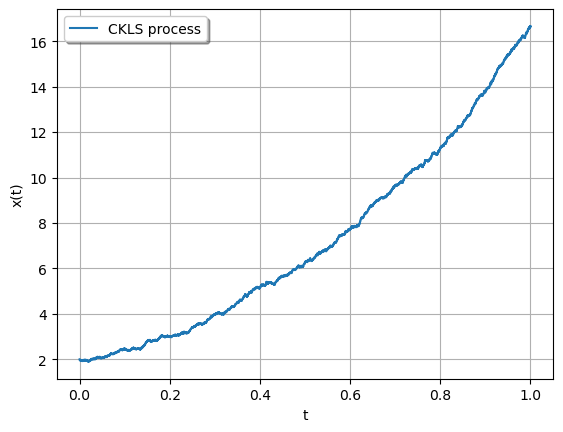

In [38]:
plt.plot(t_data, x_data_CKLS[:,0], label = 'CKLS process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [39]:
CKLSp.EulerEstimation(t_data, x_data_CKLS)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -33412.65138646547
        x: [ 1.111e+00  1.856e+00  4.912e-01  3.108e-01]
      nit: 19
      jac: [-3.456e-01  6.912e-02  4.875e-02  4.511e-02]
     nfev: 120
     njev: 24
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [40]:
#Confidence intervals
n = 50
result = np.zeros((n, 4))
for k in range(0, n):
    t_data, x_data_CKLS = CKLSp.EulerSolution()
    result[k] = CKLSp.EulerEstimation(t_data, x_data_CKLS).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 4):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 1.033164793431436 +- 0.19398618652123892 with 95.0% prob
theta1 = 1.9929585923793776 +- 0.05112083683225141 with 95.0% prob
theta2 = 0.4985399288233778 +- 0.003134095574073332 with 95.0% prob
theta3 = 0.3004434821698319 +- 0.003406214454885851 with 95.0% prob


Task 4. Consider the Vasicek model
$$
dX_{t} = \theta_{1} (\theta_{2}- X_{t}) dt + \theta_{3} dW_{t},\qquad X_{0}=5
$$
with $\theta_{1}=3$, $\theta_{2}=2$ and $\theta_{3}=0.5$.

Use the Ozaki method and
*   generate the sample data $X_{t_i}$, time step $\Delta t =10^{-2}$,
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [41]:
Nx = 1
Nt = 100

T = 1

params_OU = np.array([3, 2, 0.5])

x0 = 5
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [42]:
OUp.OzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -162.66526249832543
        x: [ 3.012e+00  1.901e+00  4.778e-01]
      nit: 19
      jac: [-3.467e-04  6.224e-04  2.262e-03]
     nfev: 104
     njev: 26
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [43]:
#Confidence intervals
n = 50
result = np.zeros((n, 3))
for k in range(0, n):
    t_data, x_data_OU = OUp.EulerSolution()
    result[k] = OUp.OzakiEstimation(t_data, x_data_OU).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 3):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 3.229995119598111 +- 0.2073709474347067 with 95.0% prob
theta1 = 1.9832718419659463 +- 0.08421993634472162 with 95.0% prob
theta2 = 0.3858319809558214 +- 0.09384781990493306 with 95.0% prob


Task 5. Consider the model
$$
  dX_{t} = a(t)X_{t} dt + \theta_{2}X_{t} dW_{t},\qquad X_{0}=10
$$
with $a(t) = \theta_{1}t$, $\theta_{1}=-2$, $\theta_{2}=0.2$.

Use the Shoji-Ozaki method and:
* generate the sample data $X_{t_i}$ time step $\Delta t =10^{-3}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.

In [44]:
Nx = 1
Nt = 1000

T = 1

params_T5 = np.array([-2, 0.2])

x0 = 5
init_state = x0 * np.ones(Nx)

T5p = Task5process(params_T5, T, Nx, Nt, init_state)

t_data, x_data_T5 = T5p.EulerSolution()

In [45]:
T5p.ShojiOzakiEstimation(t_data, x_data_T5)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -2408.91344906601
        x: [-1.672e+00  2.010e-01]
      nit: 15
      jac: [ 6.248e-02 -2.864e-01]
     nfev: 135
     njev: 45
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

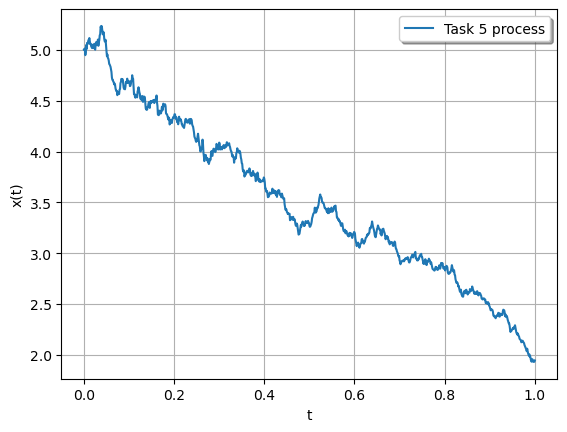

In [46]:
plt.plot(t_data, x_data_T5[:,0], label = 'Task 5 process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [47]:
#Confidence intervals
n = 50
result = np.zeros((n, 2))
for k in range(0, n):
    t_data, x_data_T5 = T5p.EulerSolution()
    result[k] = T5p.ShojiOzakiEstimation(t_data, x_data_T5).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 2):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = -1.912493235272124 +- 0.10366305222322231 with 95.0% prob
theta1 = 0.17581133786726505 +- 0.027495099998602463 with 95.0% prob


Task 6. Consider the Hull-White (extended Vasicek) model
$$
  dX_{t} = a(t)(b(t)-X_{t}) dt + \sigma(t) dW_{t},\qquad X_{0}=2
$$
with $a(t) = \theta_{1}t$, $b(t)=\theta_{2}\sqrt{t}$, the volatility depends on time $\sigma(t)=\theta_{3}t$.

Generate sample data of $X_t$ with time step $\Delta t =10^{-3}$ and $\theta_{1}=3$, $\theta_{2}=1$ and $\theta_{3}=0.3$, then
use the Kessler method and:
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [48]:
Nx = 1
Nt = 100

T = 1

params_HW = np.array([3, 1, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

HWp = HullWhiteprocess(params_HW, T, Nx, Nt, init_state)

t_data, x_data_HW = HWp.EulerSolution()

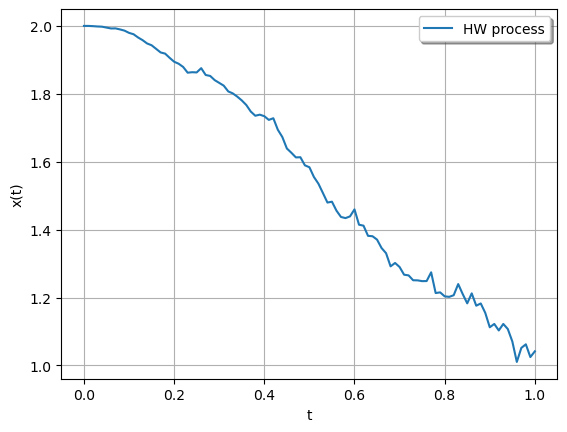

In [49]:
plt.plot(t_data, x_data_HW[:,0], label = 'HW process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [50]:
HWp.KesslerEstimation(t_data, x_data_HW)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -311.307980471134
        x: [ 2.746e+00  8.363e-01  2.849e-01]
      nit: 16
      jac: [ 1.116e-01  1.570e-01 -3.567e-01]
     nfev: 180
     njev: 45
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Take a process from previous tasks and approximation method, find the solution, compute confidence intervals, and compare results with baseline.

Plot the graph and table.

Задания по вариантам
1. Байков Илья Павлович OU + Kessler
1. Гонгапшев Астемир Султанович CKLS + Shoji-Ozaki
1. Кудинкина Екатерина Андреевна CKLS + Kessler
1. Кулига Андрей Владимирович Vasicek + Euler
1. Мартыненко Александр Станиславович Vasicek + Shoji-Ozaki
1. Мироманов Даниил Борисович Vasicek + Kessler
1. Паршаков Никита Сергеевич extended Vasicek + Euler
1. Петренко Влада Витальевна extended Vasicek + Ozaki
1. Тумачев Серафим Дмитриевич extended Vasicek + Shoji-Ozaki
1. Хубиев Касымхан Юсуфович model 5 + Euler
1. Ширяева Софья Игоревна model 5 + Ozaki
1. Якунин Сергей Александрович model 5 + Kessler
1. Трофимов Яков Георгиевич CKLS + Ozaki


In [51]:
# your code

Задание 1. Сравнительный анализ точного и численного MLE

1. Для процесса Орнштейна-Уленбека (модель Вазичека) сгенерируйте траекторию процесса, параметры $\theta = (\theta_1, \theta_2, \theta_3)$ укажите самостоятельно.

2. Вычислите оценки параметров двумя способами: аналитически и численно минимизируя функцию отрицательного логарифма правдоподобия (`MLogLik`) с использованием схемы Эйлера.

3. Оцените абсолютную относительную ошибку численного метода по сравнению с аналитическим решением.

4. Сделайте выводы.


In [52]:
theta_true = np.array([3, 1, 2])
Nx, Nt, T = 1000, 100, 1
x0 = 1

# Генерация
OUp = OUprocess(theta_true, T, Nx, Nt, x0 * np.ones(Nx))
t_data, x_data = OUp.EulerSolution()
x = x_data[:, 0]
dt = T / Nt

# Аналитическое MLE
theta2_a = -1/dt * np.log(np.sum(x[:-1]*x[1:]) / max(np.sum(x[:-1]**2), 1e-10))
theta3_a = np.sqrt(2*theta2_a / (Nt*(1-np.exp(-2*dt*theta2_a))) * 
                   np.sum((x[1:] - x[:-1]*np.exp(-dt*theta2_a))**2))

# Численное MLE
theta_num = OUp.EulerEstimation(t_data, x_data).x

print(f"Истинные: θ1={theta_true[0]}, θ2={theta_true[1]}, θ3={theta_true[2]}")
print(f"Аналит.:  θ2={theta2_a:.4f}, θ3={theta3_a:.4f}")
print(f"Числен.:  θ1={theta_num[0]:.4f}, θ2={theta_num[1]:.4f}, θ3={theta_num[2]:.4f}")

Истинные: θ1=3, θ2=1, θ3=2
Аналит.:  θ2=-0.1945, θ3=1.8790
Числен.:  θ1=2.9098, θ2=0.9893, θ3=2.0002


Задача 2. Оценивание параметров в семействе моделей CKLS

1. Используя модель Чана-Карольи-Лонгстаффа-Сандерса (CKLS) реализуйте класс `CKLSprocess` и сгенерируйте данные с малым шагом $\Delta t = 10^{-4}$.

2. Примените метод Эйлера для оценки вектора параметров $\theta = (\theta_1, \theta_2, \theta_3, \theta_4)$.

3. Проведите $n=50$ симуляций процесса и постройте 95% доверительные интервалы для каждого параметра, используя t-распределение Стьюдента.

4. Сделайте выводы.



In [53]:
# Параметры CKLS
theta_true = np.array([1, 2, 0.5, 0.3])
Nx, Nt, T = 1, 10000, 1
x0 = 2

CKLS = CKLSprocess(theta_true, T, Nx, Nt, x0 * np.ones(Nx))

# 50 симуляций
n = 50
results = np.zeros((n, 4))
for i in range(n):
    t_data, x_data = CKLS.EulerSolution()
    results[i] = CKLS.EulerEstimation(t_data, x_data).x

# Доверительные интервалы
alpha = 0.05
q = t.ppf(1 - alpha/2, n - 1)
for i in range(4):
    mean = np.mean(results[:, i])
    std = np.std(results[:, i], ddof=1)
    ci = std * q / np.sqrt(n)
    print(f"θ{i}: {mean:.4f} ± {ci:.4f} (истинное: {theta_true[i]})")

θ0: 1.1634 ± 0.1953 (истинное: 1.0)
θ1: 1.9580 ± 0.0411 (истинное: 2.0)
θ2: 0.4973 ± 0.0034 (истинное: 0.5)
θ3: 0.3028 ± 0.0037 (истинное: 0.3)


Задача 3. Локальная линеаризация (Метод Озаки)

1. Для модели Вазичека с фиксированным $\sigma$ реализуйте оценку параметров методом Озаки.
2.  Сравните результаты метода Озаки с методом Эйлера при различных шагах дискретизации $\Delta t \in \{10^{-1}, 10^{-2}, 10^{-3}\}$.
3. Подтвердите теоретический вывод о том, что методы локальной линеаризации работают лучше метода Эйлера при увеличении шага $\Delta t$.
4. Сделайте выводы.

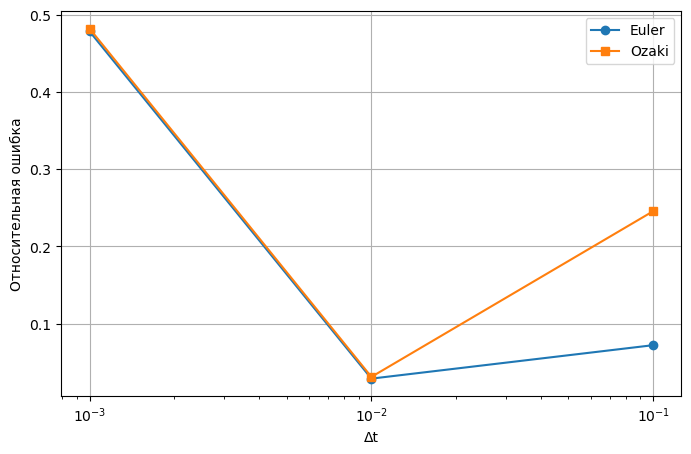

In [54]:
theta_true = np.array([3, 2, 0.5])
Nx, T = 1, 1
x0 = 5

dts = [1e-1, 1e-2, 1e-3]
errors_euler, errors_ozaki = [], []

for dt in dts:
    Nt = int(T / dt)
    OU = OUprocess(theta_true, T, Nx, Nt, x0 * np.ones(Nx))
    t_data, x_data = OU.EulerSolution()
    
    euler_est = OU.EulerEstimation(t_data, x_data).x
    ozaki_est = OU.OzakiEstimation(t_data, x_data).x
    
    errors_euler.append(np.linalg.norm(euler_est - theta_true) / np.linalg.norm(theta_true))
    errors_ozaki.append(np.linalg.norm(ozaki_est - theta_true) / np.linalg.norm(theta_true))

# График
plt.figure(figsize=(8, 5))
plt.semilogx(dts, errors_euler, 'o-', label='Euler')
plt.semilogx(dts, errors_ozaki, 's-', label='Ozaki')
plt.xlabel('Δt'); plt.ylabel('Относительная ошибка')
plt.legend(); plt.grid(True); plt.show()

Задача 4. Оценивание моделей с временной зависимостью (Метод Кесслера)

1. Рассмотрите расширенную модель Вазичека (модель Халла-Уайта), где коэффициенты зависят от времени.

2. Используйте метод Кесслера и оцените параметры сноса и диффузии по траектории, сгенерированной с параметрами $(3.0, 1.0, 0.3)$, $\Delta t = 10^{-3}$.

3. Рассчитайте матрицу ковариации оценок параметров.

4. Сделайте выводы.


In [61]:
theta_true = np.array([3, 1, 0.3])
Nx, Nt, T = 1, 1000, 1
x0 = 2

HW = HullWhiteprocess(theta_true, T, Nx, Nt, x0 * np.ones(Nx))
t_data, x_data = HW.EulerSolution()

# Оценка Кесслера
result = HW.KesslerEstimation(t_data, x_data)
theta_est = result.x

# Ковариационная матрица (аппроксимация обратным Гессианом)
cov_matrix = result.hess_inv * np.eye(len(theta_est))
print("Оценки:", theta_est)
print("Ковариационная матрица:\n", cov_matrix)

Оценки: [1.0292536  1.00328469 0.30168286]
Ковариационная матрица:
 [[ 1.08774364 -0.06110371 -0.33857382]
 [-0.06110371  0.38654889 -0.20752469]
 [-0.33857382 -0.20752469  0.2394137 ]]


Задача 5. Исследование схем наблюдений

1. Проведите эксперимент, сравнивающий точность оценок в зависимости от дизайна эксперимента:
*   Large sample scheme: $\Delta=const$, увеличивающееся $n$ (общее время $T \to \infty$).
*   High-frequency scheme: Фиксированное $T=const$, уменьшающийся шаг $\Delta \to 0$.
2. Установите, как меняется смещение (bias) и дисперсия оценок параметров сноса и диффузии при переходе от одной схемы к другой. Подкрепите выводы иллюстративными графиками.

3. Сделайте выводы.

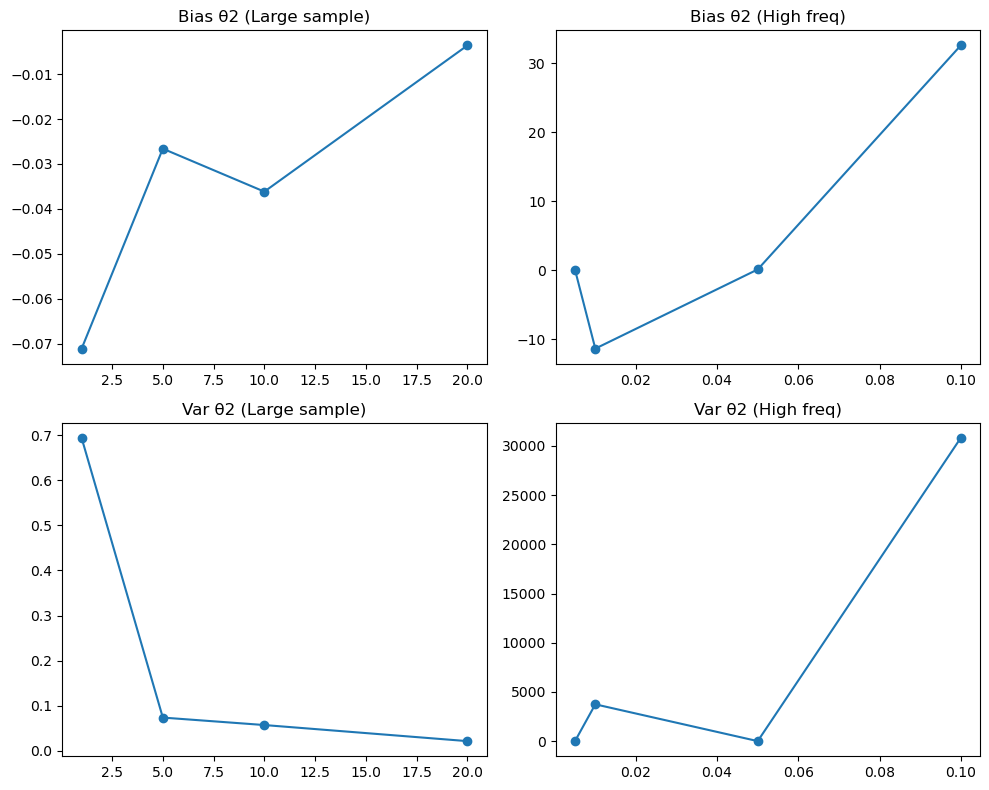

In [56]:
def run_scheme(T, Nt, scheme='large'):
    OU = OUprocess(np.array([3, 1, 2]), T, 1, Nt, np.array([1]))
    t_data, x_data = OU.EulerSolution()
    return OU.EulerEstimation(t_data, x_data).x

# Large sample: фикс. Δt, растет T
dt_fixed = 0.01
T_range = [1, 5, 10, 20]
bias_large, var_large = [], []
for T in T_range:
    ests = [run_scheme(T, int(T/dt_fixed)) for _ in range(30)]
    bias_large.append(np.mean(ests, axis=0) - [3, 1, 2])
    var_large.append(np.var(ests, axis=0))

# High frequency: фикс. T, уменьшается Δt
T_fixed = 1
dt_range = [0.1, 0.05, 0.01, 0.005]
bias_hf, var_hf = [], []
for dt in dt_range:
    ests = [run_scheme(T_fixed, int(T_fixed/dt)) for _ in range(30)]
    bias_hf.append(np.mean(ests, axis=0) - [3, 1, 2])
    var_hf.append(np.var(ests, axis=0))

# Графики
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0,0].plot(T_range, [b[1] for b in bias_large], 'o-'); axes[0,0].set_title('Bias θ2 (Large sample)')
axes[0,1].plot(dt_range, [b[1] for b in bias_hf], 'o-'); axes[0,1].set_title('Bias θ2 (High freq)')
axes[1,0].plot(T_range, [v[1] for v in var_large], 'o-'); axes[1,0].set_title('Var θ2 (Large sample)')
axes[1,1].plot(dt_range, [v[1] for v in var_hf], 'o-'); axes[1,1].set_title('Var θ2 (High freq)')
plt.tight_layout(); plt.show()